In [1]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math
# os.environ['THEANO_FLAGS'] = "device=cuda0,force_device=True,floatX=float32"
# from aesara_theano_fallback import aesara as theano
#import theano

# print(theano.config.device)
# import sys, getopt
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/"

data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2_reduced_dense10/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model3/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run1/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel9_run3/"
model = load_model(data_folder+"tbinet.h5")
# model.load_weights("/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff//model2_reduced_dense10/tbinet.38-0.08.hdf5")
# model.load_weights("/Users/yibeijia/Downloads/nucleosome_occupancy/tbinet_stuff/model2/tbinet.22-0.21.hdf5")


In [3]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 147, 4)]     0                                            
__________________________________________________________________________________________________
conv1d (Conv1D)                 (None, 147, 320)     13120       input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling1d (MaxPooling1D)    (None, 143, 320)     0           conv1d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 143, 320)     0           max_pooling1d[0][0]              
______________________________________________________________________________________________

In [4]:
layer_names = [layer.name for layer in model.layers]
layer_names

['input_1',
 'conv1d',
 'max_pooling1d',
 'dropout',
 'dense',
 'permute',
 'activation',
 'permute_1',
 'attention2',
 'repeat_vector',
 'permute_2',
 'multiply',
 'bidirectional',
 'dropout_1',
 'flatten',
 'dense_1',
 'activation_1',
 'dense_2',
 'activation_2']

In [5]:
attention = model.layers[8]
attention

In [6]:
layer_outputs = [layer.output for layer in model.layers]
layer_outputs

[<KerasTensor: shape=(None, 147, 4) dtype=float32 (created by layer 'input_1')>,
 <KerasTensor: shape=(None, 147, 320) dtype=float32 (created by layer 'conv1d')>,
 <KerasTensor: shape=(None, 143, 320) dtype=float32 (created by layer 'max_pooling1d')>,
 <KerasTensor: shape=(None, 143, 320) dtype=float32 (created by layer 'dropout')>,
 <KerasTensor: shape=(None, 143, 1) dtype=float32 (created by layer 'dense')>,
 <KerasTensor: shape=(None, 1, 143) dtype=float32 (created by layer 'permute')>,
 <KerasTensor: shape=(None, 1, 143) dtype=float32 (created by layer 'activation')>,
 <KerasTensor: shape=(None, 143, 1) dtype=float32 (created by layer 'permute_1')>,
 <KerasTensor: shape=(None, 143) dtype=float32 (created by layer 'attention2')>,
 <KerasTensor: shape=(None, 320, 143) dtype=float32 (created by layer 'repeat_vector')>,
 <KerasTensor: shape=(None, 143, 320) dtype=float32 (created by layer 'permute_2')>,
 <KerasTensor: shape=(None, 143, 320) dtype=float32 (created by layer 'multiply')>,

In [8]:
feature_map_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

# Now analyze the layer

In [9]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)

In [10]:
# data_folder = "./data/"
data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')
d = testmat['Test_data'][::1000]

labels = testmat['Test_labels']
# print(f"labels.shape: {labels.shape}")
# print(f"labels: {labels}")
# new_labels = labels[0][:10000]
new_labels = labels[0][::1000]
print(f"new_labels.shape: {new_labels.shape}")
ones = np.flatnonzero(new_labels == np.max(new_labels))
zeros = np.flatnonzero(new_labels == np.min(new_labels))
print(f'ones.shape {ones.shape}')
print(f'zeros.shape {zeros.shape}')
# print(ones)
# print(zeros)

writeSeqToFile(d,ones,zeros)
# print(f"Total Test Seq is: {len(testmat['Test_data'])}, we take: {len(d)}")
feature_maps = feature_map_model.predict(np.transpose(d,axes=(0,1,2)))
# testmat = scipy.io.loadmat(data_folder+'SampleTest.mat')
# feature_maps = feature_map_model.predict(np.transpose(testmat['Test_data'],axes=(0,1,2)))
# feature_maps = feature_map_model.predict(np.transpose(testmat['Test_data'],axes=(0,1,2))[::1000])
# feature_maps = feature_map_model.predict(np.transpose(testmat['Test_data'],axes=(0,1,2))[:10000])
# feature_maps = model.predict(testmat['Test_data'])

new_labels.shape: (151,)
ones.shape (73,)
zeros.shape (78,)


In [25]:
# The last shape parameter, the number of channels, tells how many features there are for that layer
for layer_name, feature_map in zip(layer_names, feature_maps):print(f"The shape of the {layer_name} is =======>> {feature_map.shape}")

The shape of the input_1 is =======>> (151, 147, 4)
The shape of the conv1d is =======>> (151, 147, 320)
The shape of the max_pooling1d is =======>> (151, 143, 320)
The shape of the dropout is =======>> (151, 143, 320)
The shape of the dense is =======>> (151, 143, 1)
The shape of the permute is =======>> (151, 1, 143)
The shape of the activation is =======>> (151, 1, 143)
The shape of the permute_1 is =======>> (151, 143, 1)
The shape of the attention2 is =======>> (151, 143)
The shape of the repeat_vector is =======>> (151, 320, 143)
The shape of the permute_2 is =======>> (151, 143, 320)
The shape of the multiply is =======>> (151, 143, 320)
The shape of the bidirectional is =======>> (151, 143, 640)
The shape of the dropout_1 is =======>> (151, 143, 640)
The shape of the flatten is =======>> (151, 91520)
The shape of the dense_1 is =======>> (151, 10)
The shape of the activation_1 is =======>> (151, 10)
The shape of the dense_2 is =======>> (151, 1)
The shape of the activation_2 is

In [30]:
def plot_feature_map(y, plt_title):
    plt.rcParams["figure.figsize"] = 5,2
    # number of features is 144
    x = range(1,144)

    fig, (ax,ax2) = plt.subplots(nrows=2, sharex=True)

    extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
    ax.imshow(y[np.newaxis,:], cmap="plasma", aspect="auto", extent=extent)
    ax.set_yticks([])
    ax.set_xlim(extent[0], extent[1])

    ax2.plot(x,y)
    fig.suptitle(plt_title)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_all_feature_maps(data, plt_title):
    plt.rcParams["figure.figsize"] = 20,10
    x = range(1,135)
    fig, axis = plt.subplots()

    extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
    heatmap = axis.pcolor(data, cmap="plasma") 
    axis.set_yticks(np.arange(data.shape[0])+0.5, minor=False)
#     axis.set_xticks(np.arange(data.shape[1])+0.5, 5)
    
    row_labels = list(range(1,data.shape[0]+1))
    axis.set_yticklabels(row_labels)
#     axis.set_xticklabels(x, 5)
    fig.suptitle(plt_title)
    plt.colorbar(heatmap)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_both_feature_maps(y0, y1, plt_title):
    plt.rcParams["figure.figsize"] = 10,4
    x = range(1,135)
    data = np.concatenate(([y0], [y1]))
#     print(data)
    fig, axis = plt.subplots()

    extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
    heatmap = axis.pcolor(data, cmap="Blues") 
    axis.set_yticks(np.arange(data.shape[0])+0.5, minor=False)
#     axis.set_xticks(np.arange(data.shape[1])+0.5, 5)
    
    row_labels = ["Depleted - 0", "Enriched - 1"]
    axis.set_yticklabels(row_labels)
#     axis.set_xticklabels(x, 5)
    fig.suptitle(plt_title)
    plt.colorbar(heatmap)
    plt.tight_layout()
    plt.show()

In [27]:
len(feature_map)

151

# Plot feature map for all sequences

In [150]:
def AtrackCalc(seq):
    longest=''
#     curr_seq=''
    AllAtracks=[]
    start=0
    end=0
    count=0
    for letter in seq[1:]:
        count+=1
#         print(">>>>>>>>>>>>>")
#         print(f"current pos: {count}")
#         print(f"current letter: {letter}")        
#         print(f"last letter: {seq[count-1]}")        

        if seq[count-1] != letter: #If not equal, check sequence
            if seq[count-1]=='A' and letter=='T': #only ApT doesn't breaks Atrack\
#                 print("***ApT")
                end+=1
            else:
#                 print("A track broken")
#                 print(f"Appednign start:{start}, end:{end+1}")
                AllAtracks.append(seq[start:end+1])
                start=count
                end=count
        else: #If equal, expand sequence
#             print("equal, expand seq")
            end+=1
#         print(f"end: {end}")
        if end == len(seq)-1:
            AllAtracks.append(seq[start:end+1])
    for atrack in AllAtracks:
        if len(atrack) > len(longest):
            longest=atrack
#             longest = seq[start:end]
    return longest,AllAtracks

longest,AllAtracks = AtrackCalc('TTAATTAATT') 
# AllAtracks = AtrackCalc('AATTAC') 
print(AllAtracks)
print(longest)

['TT', 'AATT', 'AATT']
AATT


In [32]:
def AtackColor(tb):
    color_group = []
    debug = 0

    for pentamer in tb.keys():
#         if debug < 10:
#         print(pentamer)
        curr_seq = ''
        longest = ''
        for letter in pentamer:
            # Since we are tracking Atract, change all Ts to A to facilitate count because of reverse complement
#             if letter == 'T':
#                 letter = 'A'
#             if letter == 'G':
#                 letter = 'C'    
            if len(curr_seq) == 0: 
                curr_seq = letter
            else:
                # if the next letter to append is different
                if curr_seq[-1] != letter:
                    if len(curr_seq) > len(longest):
                        longest = curr_seq # Update the longest seq
                    curr_seq = letter # start the track over

                # if the next letter to append is the same
                else:
                    curr_seq += letter #continue append

                    # if we reach 5 letter, report it as the longest seq now
                    if len(curr_seq) == 5:
                        longest = curr_seq
        color_group += [longest]
#         debug += 1
#     print(color_group)
    cols = []
    for seq in color_group:
        if 'A' in seq:
            cols.append(len(seq)) 
        if 'C' in seq:
            cols.append(5+len(seq))
    return cols

In [47]:
# I/O function
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)
AllDNAshape =['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
# fileName = "/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
fileName = "/Users/yibeijia/Downloads/ProjectStuff/pentamer_table.txt"
tb = read_SD_table(fileName);
print(len(tb))

1024


In [65]:
def getLongestKmer(pentamer):
    longest = ''
    curr_atrack=''
    start =0
    end =0
    conseq_letter = ''
    count = 0
    for curr_letter in pentamer:
#         print("-------------------------")
        if curr_letter =='A' or curr_letter =='T':
    #         print(f"conseq letter is {conseq_letter}")
            curr_atrack+=curr_letter
        else:
#             print(f"(end - start) is {(end - start)}")
            if len(curr_atrack) > len(longest):
                longest =curr_atrack
            curr_atrack=''
                
    return longest
seq = ReverseOneHotEncode(d[0])
print(seq)
print(getLongestKmer(seq))

CGGAATAGCTTCACTGACTGCGTGTATTTCTGCTTCTGTAGTTGAAGTGCATGTTAACGAAGCCTTTGTCGACTTTCCTCCAATCACTTTTCCGTTGAGTAGGAAAATGTTACCAATTTGTGACTTGTAATATGGTTGGTTACCATA
TAATAT


# For each seq, sum all the 5mer shape values

In [69]:
# print((d[0]))
# print((d[1]))
# print(ReverseOneHotEncode(d[0]))
# print(ReverseOneHotEncode(d[1]))

import pandas as pd
columns=['Longest_Atack','Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
seq_dict={}
for i in range(len(d)):
    seq = ReverseOneHotEncode(d[i])
    seq_dict[seq]=[]
    longest_Atrack = len(getLongestKmer(seq))
    seq_dict[seq].append(longest_Atrack)
    for shape in columns[1:]:
        seq_curr_shape_val = 0
        for j in range(len(seq)-5+1):
            pentamer = seq[j:j+5]
            shape_index=AllDNAshape.index(shape)
            seq_curr_shape_val+=tb[pentamer][shape_index]
        seq_dict[seq].append(seq_curr_shape_val)

seq_df=pd.DataFrame.from_dict(seq_dict, orient='index',columns=columns)
seq_df 
        

,Longest_Atack,Shear,Stretch,Stagger,Buckle,ProT,Opening,MGW,EP,Shear-FL,...,Slide-FL_-1,Slide-FL_1,Rise-FL_-1,Rise-FL_1,Tilt-FL_-1,Tilt-FL_1,Roll-FL_-1,Roll-FL_1,HelT-FL_-1,HelT-FL_1
CGGAATAGCTTCACTGACTGCGTGTATTTCTGCTTCTGTAGTTGAAGTGCATGTTAACGAAGCCTTTGTCGACTTTCCTCCAATCACTTTTCCGTTGAGTAGGAAAATGTTACCAATTTGTGACTTGTAATATGGTTGGTTACCATA,6,-3.1064,-3.7994,-3.9682,-185.7853,-1138.7055,-59.2180,717.2129,-955.4010,35.3181,...,60.1601,60.5483,39.8801,40.0166,480.4447,480.0287,735.4228,736.7905,533.5727,534.2648
TTTTAACTGATATGAAGGGTCCGACTTTGTCCTTTTTCGGCCACCGCATACCCCACGGCGATGCCTCCGCTACCTGCATTTGAGTAGCATCTCCGTTTCGCGGGGTATTCGGCGCTACGTCGCCTGTTCGAGCGGCTCTGTTCGTTG,6,-0.7176,-4.0499,-1.1432,-188.2418,-924.9698,-22.6147,727.1492,-837.6977,35.1006,...,59.1592,59.2817,38.9938,38.8528,478.0506,477.1829,722.1113,721.3087,531.8529,532.5403
TGGTTCTGTATTAACTGGTATCTTTGCTGCAGACTATGTAAATGCCACTGCAGGCTCTTACATTAGTCCAATTGATGGTGGCTGGATCAATCATCACTATAAACAAGTTGGTTATCAATTAGCAGGTATATGCGCTGCACTAGCCTG,6,-1.0991,-3.9349,-3.0043,-42.3533,-1023.9698,-50.7026,741.5848,-910.4533,35.4977,...,59.8912,59.8948,39.5892,39.5823,480.5967,480.1346,729.6118,730.8661,528.2467,528.3726
CTTTTTACGTCGAAGTTATTGTATAGTTCCGACTATAGGTATACCGGGCTTTATCCTCTCTCGATTTTCTTTCTTCTGAGCACAATAGCTGCTATATTGAGACTACTTGCACTAGCGTTGGGAATGAGAACAAGGAAGAGGCTTGGT,6,-3.4347,-3.8034,-3.2974,-93.8378,-1032.3039,-50.0033,722.2657,-928.1151,35.2960,...,59.2755,59.3388,39.9415,39.8893,481.3425,481.5684,735.0254,735.0125,530.9208,531.7262
AATTAAAAAAGAATTGTAACCTTATTTAAAAAAAAAAATAGTACATAACAATAAAAAAAAAAAAGATAATAATTTTGAATTTATTGCTAGACATTCTTACGTTTATTGTGTTCATGTTAACAAAAACACATGCCCGCGGTTATTATC,19,3.4064,-3.1276,-8.8834,169.2060,-1471.7412,-127.4099,700.9581,-1085.1906,35.7138,...,61.3074,61.2144,40.4345,40.7168,481.8853,482.8076,759.8596,763.3853,539.5768,540.3252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCACGAGAAATACCATAGTCGCCAGGGAAAGAGAAGTATGGCCCGGCACCACCCAGGAATGGGAATATGTCTTCCTGAGTGCCAATTTTGGCAACATCGGCTAACTCTCCGAGGGGAATTGTACCTGCATTAACTAAAGCAGCGGCT,6,0.5041,-4.1363,-2.8659,102.7821,-935.0269,-34.2632,719.3783,-877.2640,35.2561,...,59.6635,59.4964,39.3481,39.3803,476.7384,476.4599,724.9581,723.4704,532.4038,530.9722
GTATAGCCTTTAATTCCCGTTATCTACGTTTAGCTTTGCAAAGGTTAGGATTTATTGTCTACGGTGTGGCTGACTCACCAGTTATTCCCTTACTACTGTATTGTCCCTCAAAGATGCCCGCATTTTCGAGAATGATGTTACAAAGAC,7,-0.8004,-3.7804,-3.7180,-160.7822,-1091.6657,-57.2294,722.9218,-930.5269,35.3670,...,60.0249,59.9324,39.8025,39.5682,480.7456,480.2913,739.6402,738.0712,532.1677,533.3598
TGGATGAAGAAGAAGAAGAAAAGAAATTGAAAATGATAATGATGAGTAACAAACAAAAGAAACTTTACAAAAAAATGAAGTATTCTAATGCTAAAAAGGAGGAACAAGCTGAGAACTTAAAAAAGAAAAAGAAGCAAATTGCCAAAC,8,3.2459,-3.2302,-7.5931,452.4314,-1314.0497,-103.5821,678.5015,-1077.7375,35.3507,...,61.3129,61.0478,40.4132,40.2686,479.2994,479.5583,754.7047,753.5974,542.3990,540.3239
CAGGTATCAAGCAACAGCTGTCCGTTGTTGAATGGCACCCAAAAAACTCCACAAGAGTGGCAACGGCTACTGGTAGCGATAATGATCCATCTATCCTGATCTGGGATTTAAGAAACGCCAACACACCATTGCAGACTTTAAATCAAG,7,3.4369,-3.9682,-3.6351,135.1832,-1060.7925,-49.5708,726.0600,-913.7971,35.3762,...,60.1887,60.1981,39.5803,39.4783,479.2379,478.7891,725.2657,727.3953,532.4103,532.3756


                                PCC       p-value                     Shapes
AtrackLength__Opening     -0.677049  1.380360e-21      AtrackLength__Opening
AtrackLength__ProT        -0.673236  2.808781e-21         AtrackLength__ProT
AtrackLength__Stagger     -0.654989  7.301205e-20      AtrackLength__Stagger
AtrackLength__EP          -0.648701  2.131616e-19           AtrackLength__EP
AtrackLength__Rise_-1     -0.537931  1.058162e-12      AtrackLength__Rise_-1
AtrackLength__Rise_1      -0.507820  2.826452e-11       AtrackLength__Rise_1
AtrackLength__MGW         -0.264990  1.008394e-03          AtrackLength__MGW
AtrackLength__Stretch-FL  -0.211135  9.259535e-03   AtrackLength__Stretch-FL
AtrackLength__Roll_-1     -0.203477  1.221554e-02      AtrackLength__Roll_-1
AtrackLength__Shift_1     -0.203208  1.233270e-02      AtrackLength__Shift_1
AtrackLength__Roll_1      -0.203177  1.234614e-02       AtrackLength__Roll_1
AtrackLength__Tilt_1      -0.112502  1.690274e-01       AtrackLength__Tilt_1

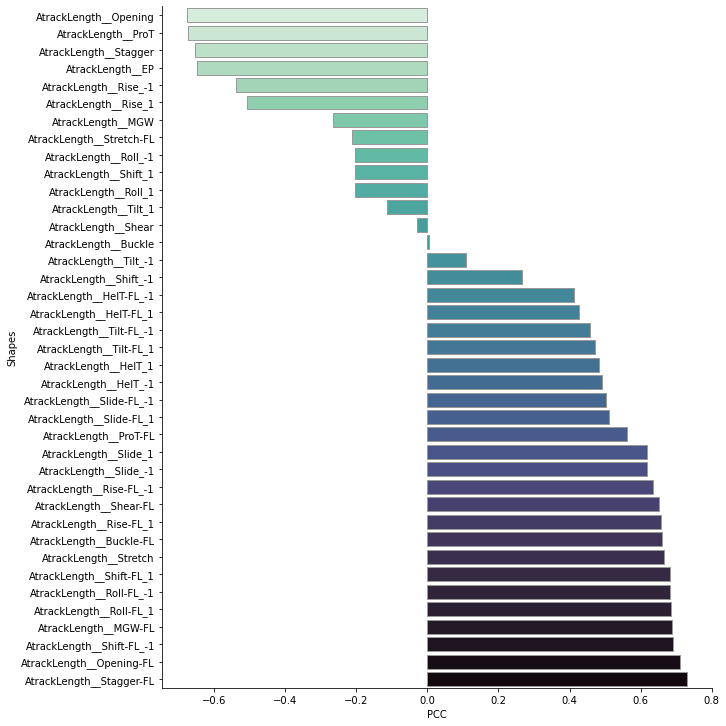

In [93]:
from pandas import *
import numpy as np
# from libraries.settings import *
from scipy.stats.stats import pearsonr
import itertools

correlations = {}
for col in columns[1:]:
    correlations['AtrackLength' + '__' + str(col)] = pearsonr(seq_df.loc[:, 'Longest_Atack'], seq_df.loc[:, col])

result = DataFrame.from_dict(correlations, orient='index')
result.columns = ['PCC', 'p-value']
result["Shapes"] =correlations.keys()
result_sorted = result.sort_values(by=['PCC'])
rank = result_sorted["PCC"].argsort().argsort()
p= sns.color_palette("mako", len(result_sorted))
print(result_sorted)

ax = sns.catplot(y="Shapes",x="PCC",data=result_sorted, kind="bar", edgecolor=".6", height=10,palette=np.array(p[::-1])[rank])

In [79]:
#################### Add person correlation annotation All Normalized ###################
def plotAttention(whichAttention, shape_order, title):
    from scipy import stats
    AllDNAshape = ['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1']
    
    all_shape_df = {}
    for shape in AllDNAshape:
        cor = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        pval = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]
        r2 = stats.pearsonr(shape_df[shape], shape_df[whichAttention])[0]**2
        all_shape_df[shape] = [cor]

    #     print(f"{shape} vs. attention_score | Pearson: {cor:.5f}, P-value {pval:.5f} | R^2: {r2:.5f}")

    df = pd.DataFrame.from_dict(all_shape_df, orient='index', columns=['Pearson'])
    df["Shapes"] =all_shape_df.keys()
    
#     if (whichAttention == 'attention_score' or whichAttention == 'attention_score_norm'):
    if (whichAttention == 'attention_score'):
        df_sorted = df.sort_values(by=['Pearson'])
        shape_order = df_sorted['Shapes']
    else:
        for s in range(len(shape_order)):
            df.loc[shape_order[s], 'order'] = s
        df_sorted = df.sort_values(by=['order'])
#     p= sns.color_palette("Greens_d", len(df_sorted))
    p= sns.color_palette("mako", len(df_sorted))
    rank = df_sorted["Pearson"].argsort().argsort()
    
    #rocket
    ax = sns.catplot(y="Shapes",x="Pearson",data=df_sorted, kind="bar", edgecolor=".6", height=10,palette=np.array(p[::-1])[rank])

    ax.set_axis_labels("Pearson Correlation", "Shapes", fontsize=18)
    ax.set_yticklabels(fontsize=12)
    ax.set_xticklabels(fontsize=12)
    ax.set_titles(title,fontsize=12)

    plt.tight_layout()
#     plt.title(whichAttention)
#     if whichAttention == 'attention_score': whichAttention=whichAttention+"_all"
#     if whichAttention == 'attention_score_norm': whichAttention=whichAttention+"norm_all"
#     plt.savefig( fig_path + whichAttention + '.png', dpi=200, bbox_inches='tight')
    return shape_order


In [ ]:
################################### Correlation plots for DNA shape ###################################
import seaborn as sns
import matplotlib.pyplot

# use added reverse complement score way
attention_score0 = []
attention_score1 = []
attention_score = []
attention_score_norm0 = []
attention_score_norm1 = []
attention_score_norm = []

for k in tb.items(): # set values to the 5mer order as seen in tb
    attention_score.append(ordered_map_add[k[0]]) 
    attention_score0.append(ordered_map_add0[k[0]])
    attention_score1.append(ordered_map_add1[k[0]])
    
    attention_score_norm.append(ordered_map_add_norm[k[0]]) 
    attention_score_norm0.append(ordered_map_add_norm0[k[0]])
    attention_score_norm1.append(ordered_map_add_norm1[k[0]])

# shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
# 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1','Tilt_-1', 'Tilt_1', 
# 'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
# 'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
# 'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
# 'mingd-SD', 'majgw-SD', 'majgd-SD'])

shape_df =  pd.DataFrame.from_dict(tb,orient='index', columns=['Shear', 'Stretch', 'Stagger', 
'Buckle', 'ProT', 'Opening', 'MGW', 'EP', 'Shear-FL', 'Stretch-FL', 'Stagger-FL', 'Buckle-FL',
'ProT-FL', 'Opening-FL', 'MGW-FL', 'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1',
'Rise_1', 'Tilt_-1', 'Tilt_1', 'Roll_-1', 'Roll_1', 'HelT_-1', 'HelT_1', 'Shift-FL_-1', 
'Shift-FL_1', 'Slide-FL_-1', 'Slide-FL_1', 'Rise-FL_-1', 'Rise-FL_1', 'Tilt-FL_-1', 'Tilt-FL_1', 
'Roll-FL_-1', 'Roll-FL_1', 'HelT-FL_-1', 'HelT-FL_1'])
print(shape_df)
shape_df['attention_score'] = attention_score
shape_df['attention_score0'] = attention_score0
shape_df['attention_score1'] = attention_score1

shape_df['attention_score_norm'] = attention_score_norm
shape_df['attention_score_norm0'] = attention_score_norm0
shape_df['attention_score_norm1'] = attention_score_norm1

shape_ordered = plotAttention('attention_score', [],'Attention Score' )
plotAttention('attention_score0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences')
plotAttention('attention_score1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences' )

# shape_ordered = plotAttention('attention_score_norm', [],'Attention Score Normalized' )
plotAttention('attention_score_norm', shape_ordered,'Attention Score Normalized' )
plotAttention('attention_score_norm0', shape_ordered, 'Attention Score for Nucleosome Depleted Sequences Normalized')
plotAttention('attention_score_norm1', shape_ordered, 'Attention Score for Nucleosome Enriched Sequences Normalized' )



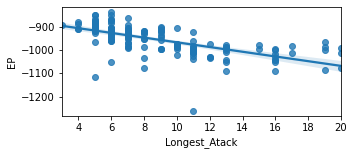

In [71]:
import seaborn as sns
sns.regplot(x="Longest_Atack",
            y="EP", 
            data=seq_df);

151
Total number of Enriched 73
Total number of Depleted 78


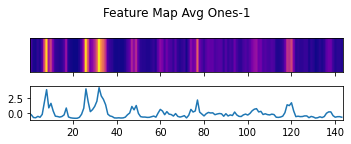

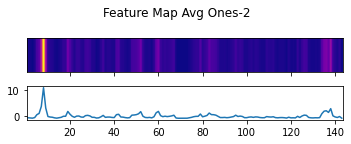

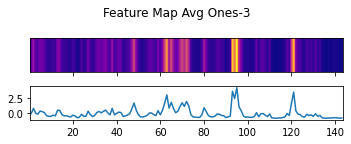

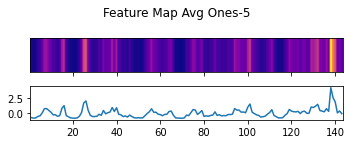

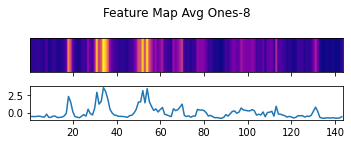

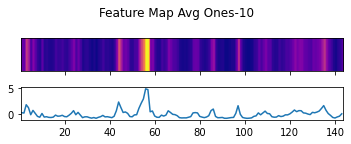

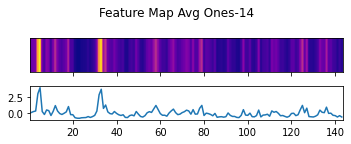

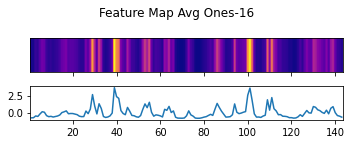

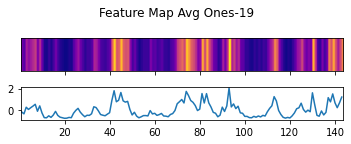

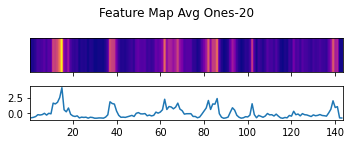

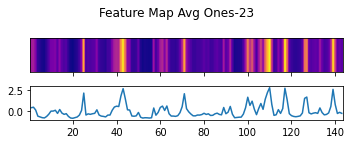

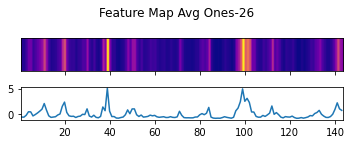

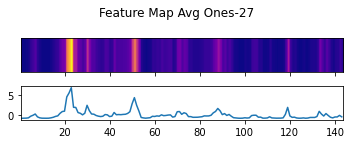

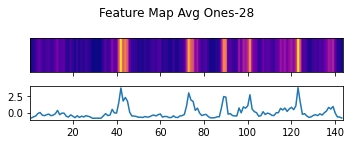

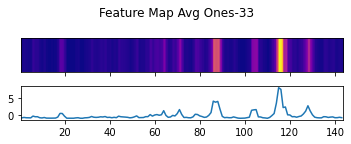

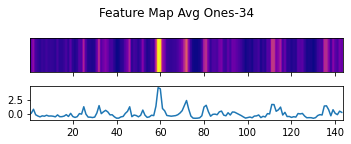

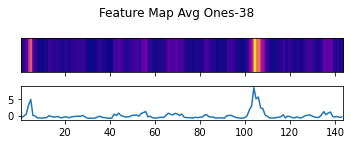

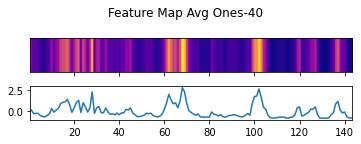

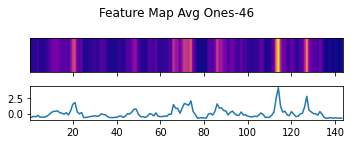

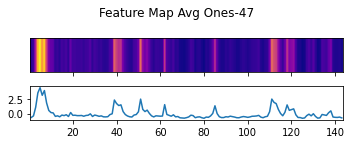

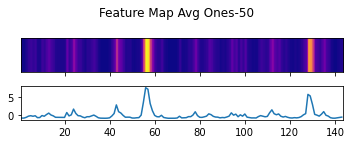

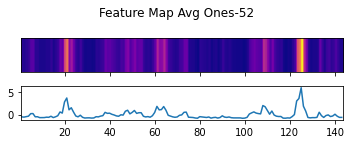

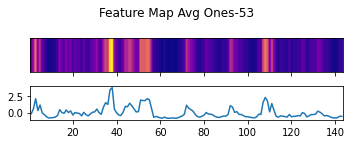

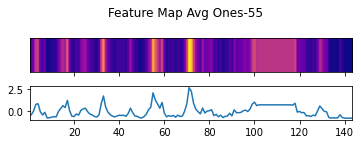

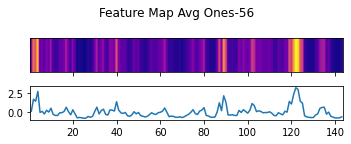

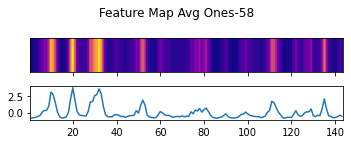

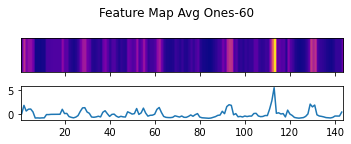

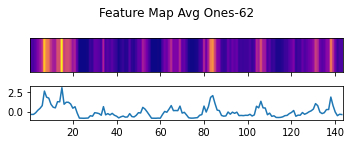

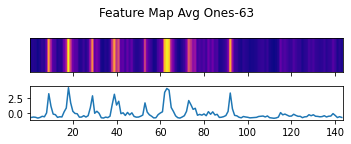

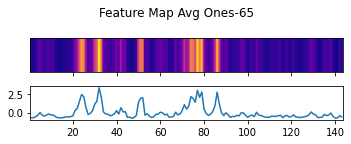

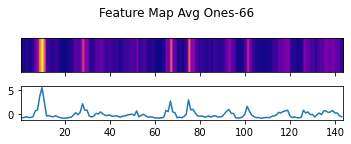

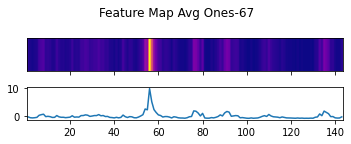

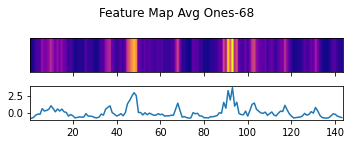

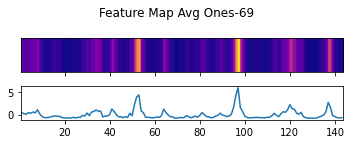

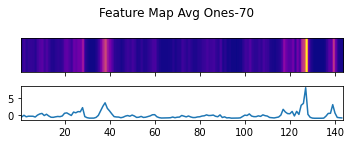

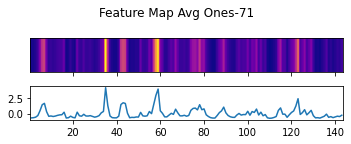

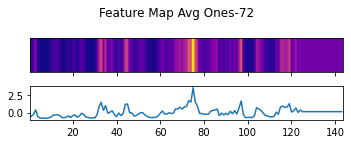

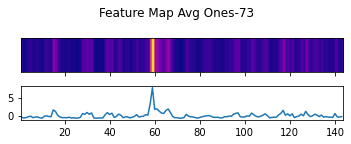

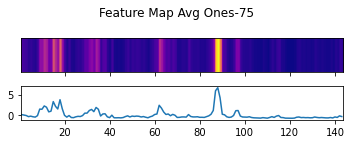

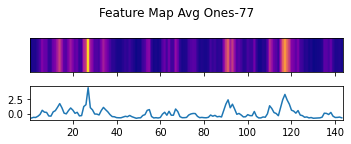

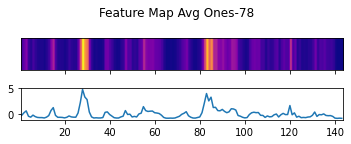

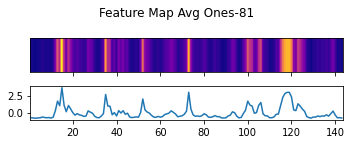

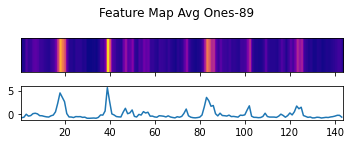

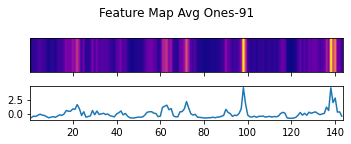

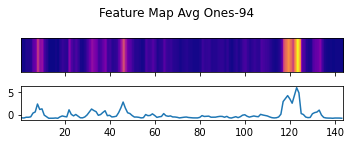

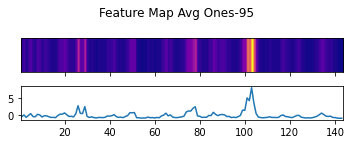

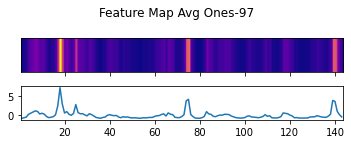

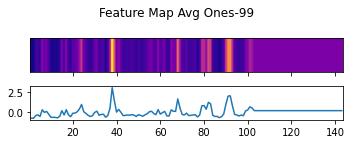

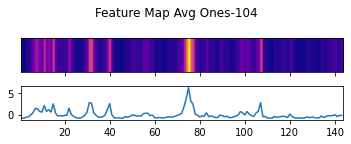

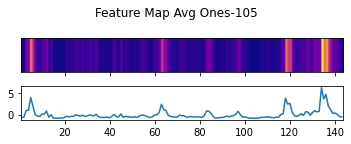

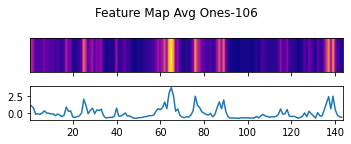

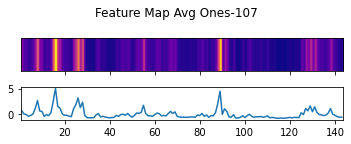

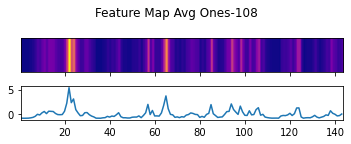

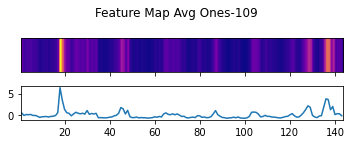

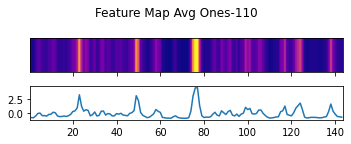

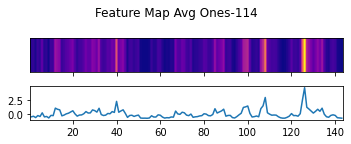

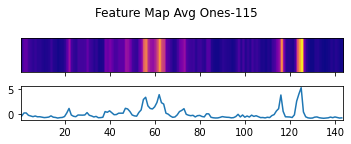

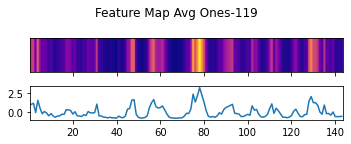

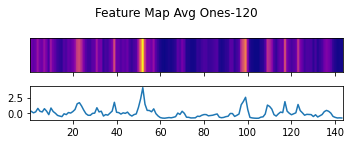

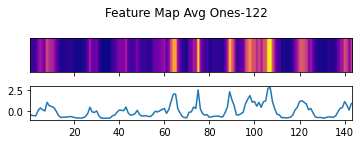

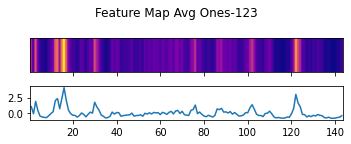

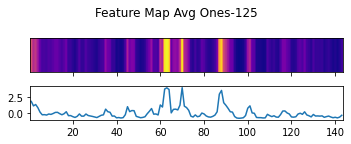

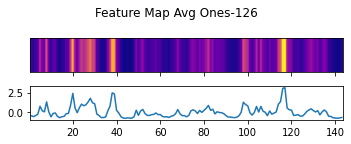

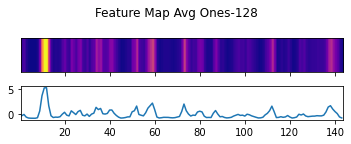

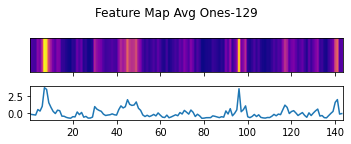

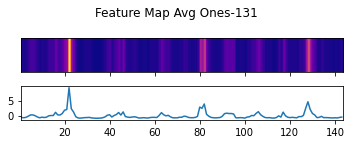

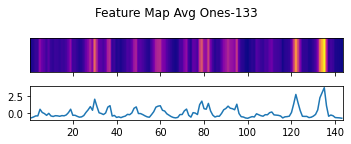

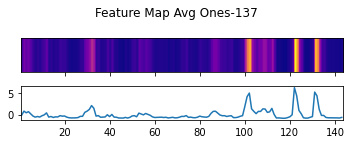

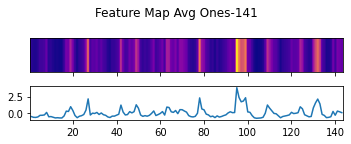

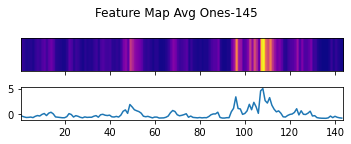

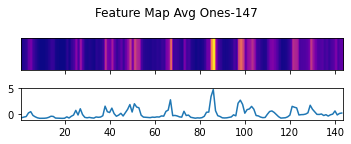

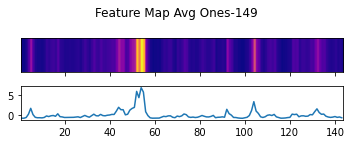

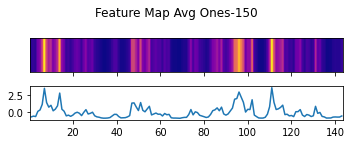

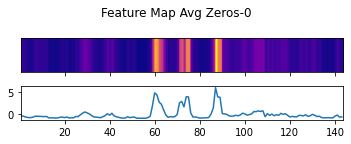

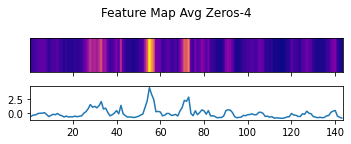

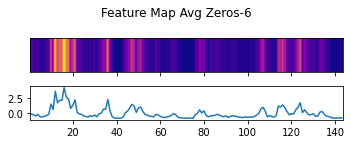

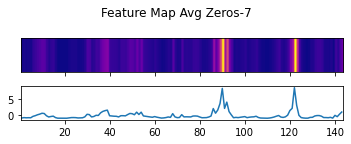

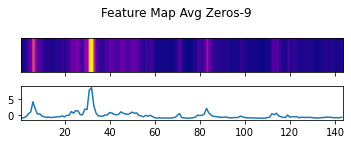

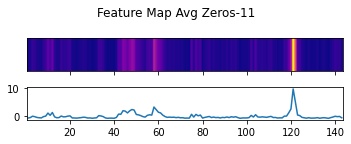

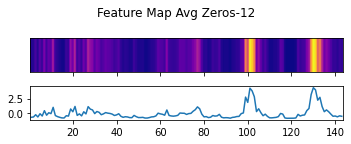

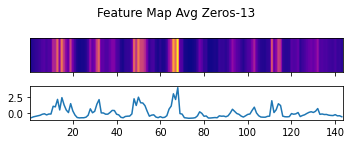

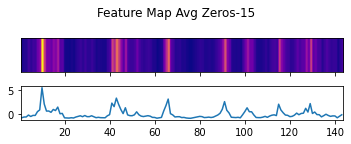

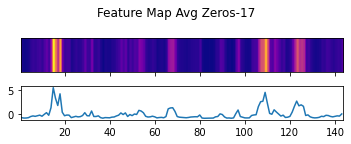

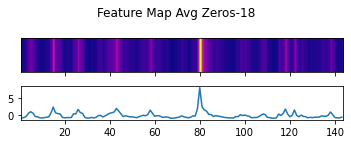

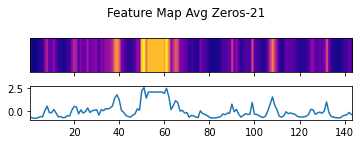

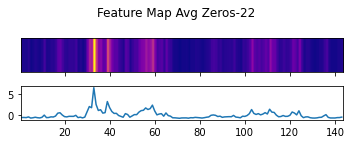

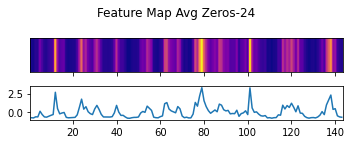

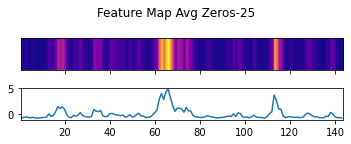

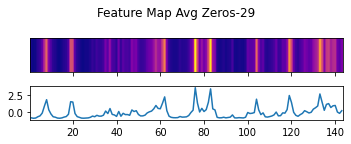

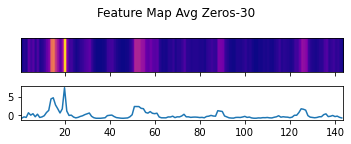

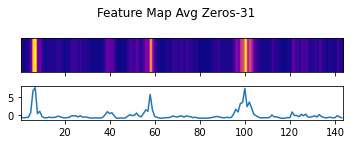

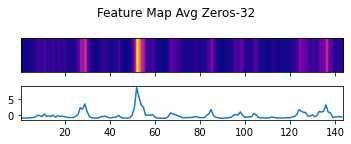

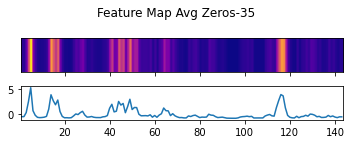

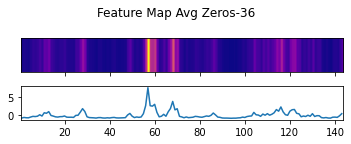

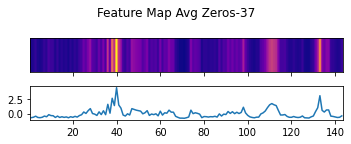

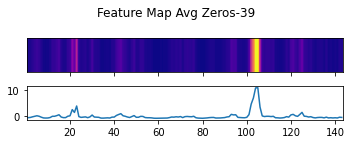

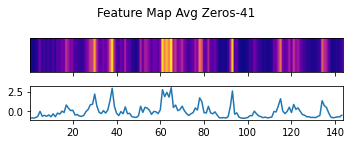

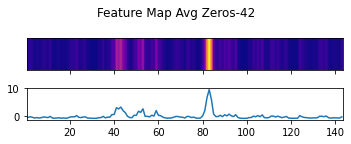

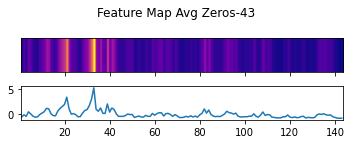

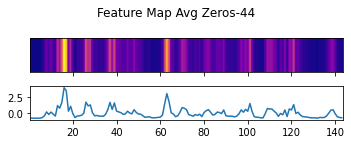

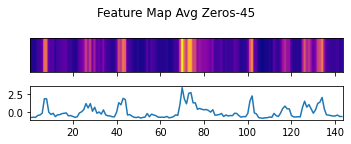

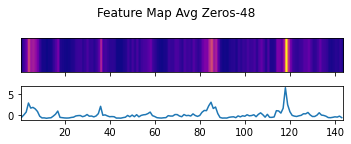

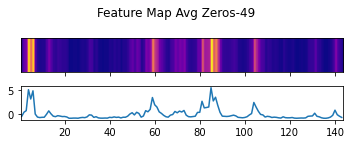

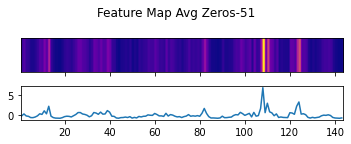

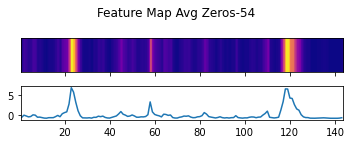

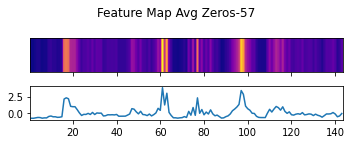

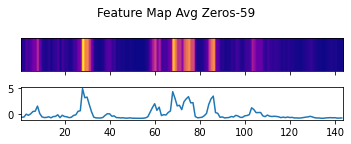

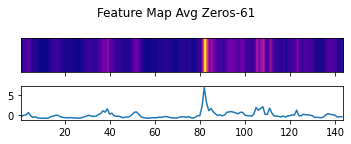

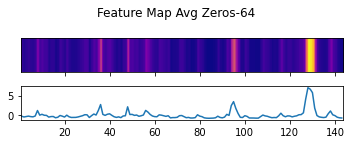

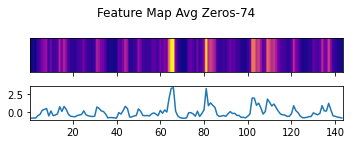

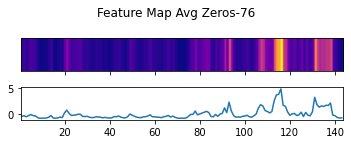

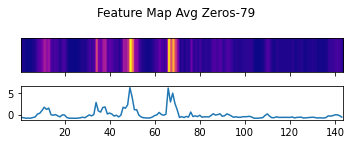

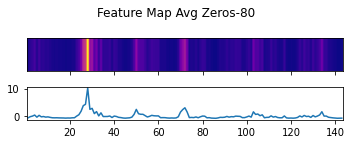

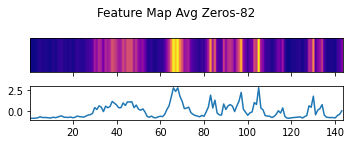

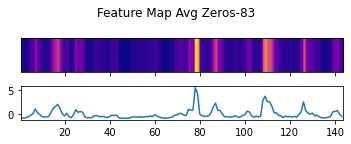

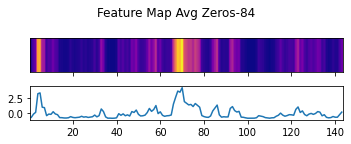

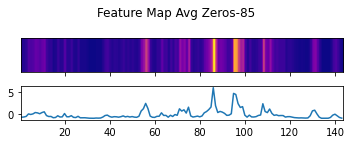

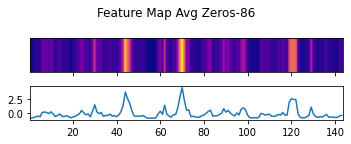

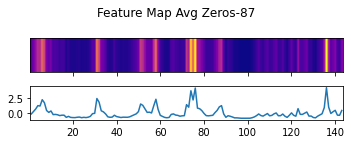

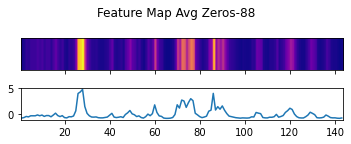

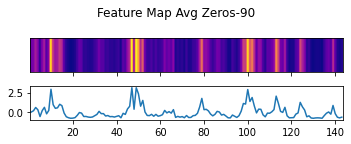

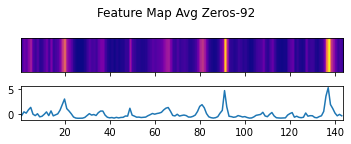

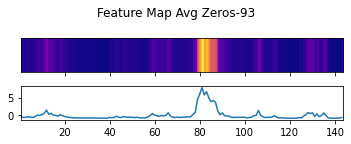

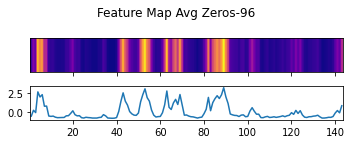

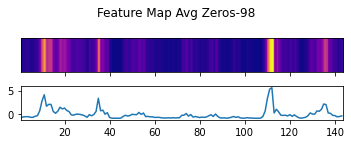

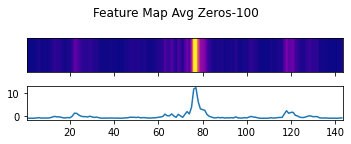

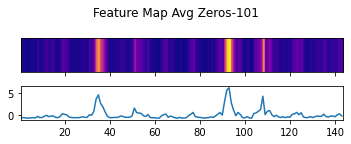

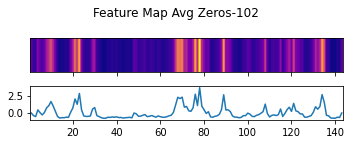

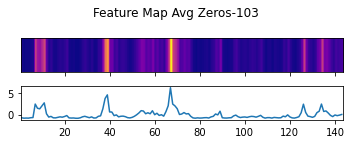

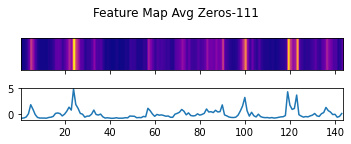

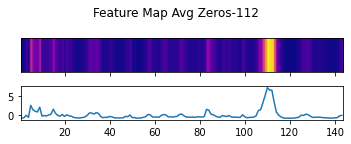

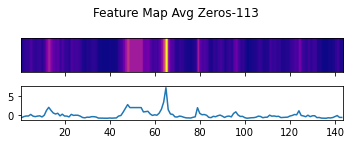

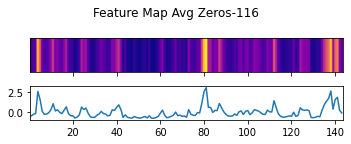

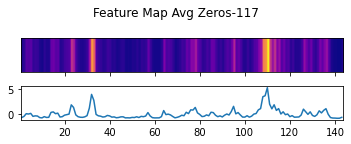

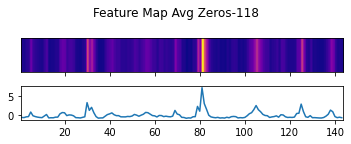

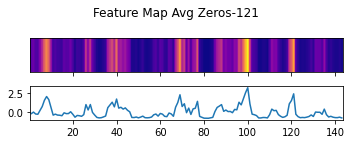

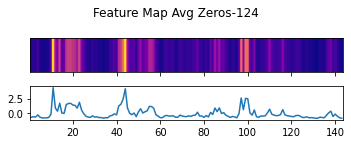

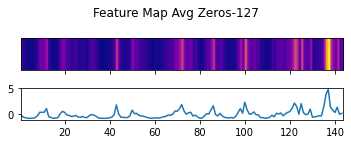

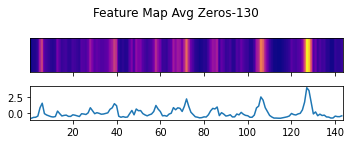

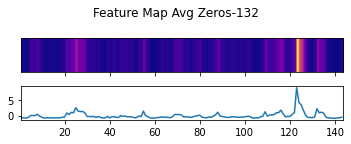

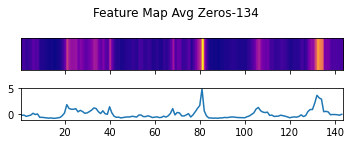

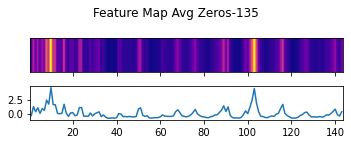

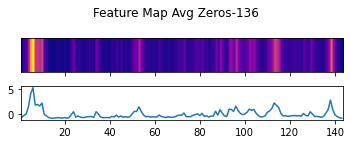

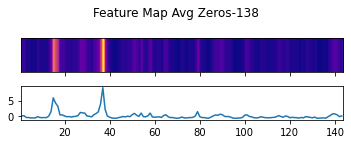

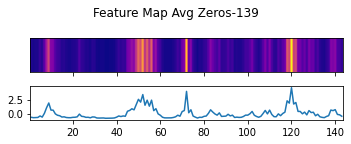

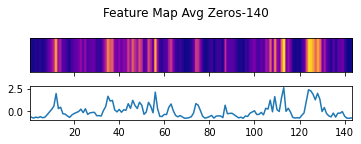

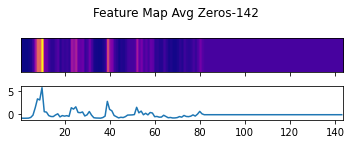

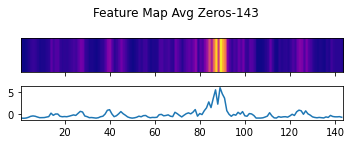

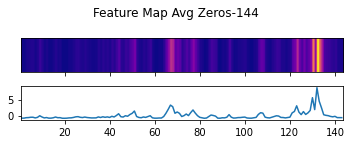

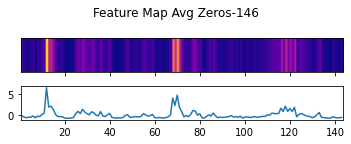

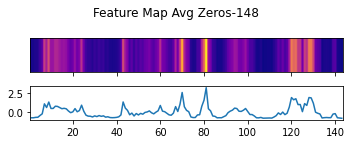

In [31]:
for layer_name, feature_map in zip(layer_names, feature_maps):

    if layer_name == 'attention2':
        
        print(len(feature_map))
        feature_map -= feature_map.mean()
        feature_map /= feature_map.std ()
#         print(f'layer_name: {layer_name}')
#         print(f'feature_map.shape: {feature_map.shape}')
        print(f"Total number of Enriched {len(ones)}" )
        print(f"Total number of Depleted {len(zeros)}" )
        for i in ones:
            feature_map_ones = feature_map[i]
            name = "Feature Map Avg Ones-" + str(i) 
            plot_feature_map(feature_map_ones, name)
            
        for i in zeros:
            feature_map_zeros = feature_map[i]
            name = "Feature Map Avg Zeros-" + str(i) 
            plot_feature_map(feature_map_zeros, name)
        
#         feature_map_ones1 = feature_map[1]
#         feature_map_zeros2 = feature_map[2]
#         feature_map_zeros3 = feature_map[3]
#         print(zeros)
#         print(f'feature_map_ones.shape: {feature_map_ones.shape}')
#         print(f'feature_map_zeros.shape: {feature_map_zeros.shape}')
#         feature_map_avg_ones0 = feature_map_ones.sum(axis=0)
#         feature_map_avg_zeros = feature_map_zeros.sum(axis=0)
#         feature_map_avg_zeros1 = feature_map[1]
#         feature_map_avg_zeros2 = feature_map[2]
#         feature_map_avg_zeros3 = feature_map[3]
#         feature_map_avg_zeros4 = feature_map[4]
#         print(feature_map_zeros)
#         plot_feature_map(feature_map_avg_ones, "Feature Map Avg Ones")
#         plot_feature_map(feature_map_avg_zeros1, "Feature Map Avg Zeros")
#         plot_feature_map(feature_map_ones0, "Feature Map Avg Ones")
#         plot_feature_map(feature_map_ones1, "Feature Map Avg Ones")
#         plot_feature_map(feature_map_zeros2, "Feature Map Avg Zeros")
#         plot_feature_map(feature_map_zeros3, "Feature Map Avg Zeros")
#         plot_feature_map(feature_map_avg_zeros4, "Feature Map Avg Zeros")
#         plot_both_feature_maps(feature_map_avg_ones, feature_map_avg_zeros1, feature_map_avg_zeros2,"Feature Maps Reduced Model") 


feature_map_ones.shape: (73, 143, 320)
feature_map_zeros.shape: (78, 143, 320)


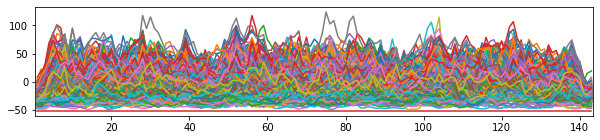

In [21]:
#### Plot each feature in permute_1 for all sequences
# The shape of the permute_1 is =======>> (# seqs (150), 134, 1)

for layer_name, feature_map in zip(layer_names, feature_maps):

    if layer_name == 'multiply':
#         print(feature_map)
        feature_map -= feature_map.mean()
        feature_map /= feature_map.std ()
#         print(f'layer_name: {layer_name}')
#         print(f'feature_map.shape: {feature_map.shape}')
        feature_map_ones = feature_map[ones]
        feature_map_zeros = feature_map[zeros]
        print(f'feature_map_ones.shape: {feature_map_ones.shape}')
        print(f'feature_map_zeros.shape: {feature_map_zeros.shape}')
        
        ################# Plot for enriched #################
        Features = []
        for seqArr in feature_map_ones:
            # make feature array a 1x134 array and sum over all seqs
            newSeqArr = np.transpose(seqArr)
            if(len(Features) == 0):
                Features=newSeqArr
            else:
                Features = Features + newSeqArr
    
        ################# Plot for depleted #################
#         Features = []
        for seqArr in feature_map_zeros:
            # make feature array a 1x134 array and sum over all seqs
            newSeqArr = np.transpose(seqArr)
            if(len(Features) == 0):
                Features=newSeqArr
            else:
                Features = Features + newSeqArr
        Features0 = np.transpose(Features)   
        
        ################## Make plots #################
        plt.rcParams["figure.figsize"] = 10,2
        # number of features is 134
        num_feature = Features.shape[1]
        x = range(1,num_feature+1)

        extent = [x[0]-(x[1]-x[0])/2., x[-1]+(x[1]-x[0])/2.,0,1]
        plt.xlim(extent[0], extent[1])
#         plt.plot(x,Features1, label='1')
#         plt.plot(x,Features0, label='0')
        plt.plot(x,Features0)
#         plt.legend()
        plt.show()


In [22]:
for layer_name, feature_map in zip(layer_names, feature_maps):

    if layer_name == 'multiply':
        print((len(feature_map[0])))

143


In [99]:
for lay in model.layers:
    print(lay.name)
#     if lay.name  == 'multiply':
#         print(lay.get_weights())
    print(lay.get_weights())
    
# How to get weight for the attention layer?


input_1
[]
conv1d
[array([[[ 0.0150284 , -0.03475809, -0.18903674, ..., -0.13573122,
         -0.680714  , -0.30054516],
        [-1.342193  , -0.00275907,  0.23811479, ..., -0.160214  ,
          0.4624109 , -0.6093448 ],
        [-0.2865409 , -0.695447  , -0.7429912 , ..., -0.11806814,
         -0.3283295 ,  0.531008  ],
        [ 0.34847164, -0.07657966,  0.21971968, ...,  0.16281621,
         -0.12871768, -0.47785294]],

       [[ 0.27695593,  0.03510001,  0.14456326, ...,  0.03742192,
         -0.16101782, -0.22912087],
        [ 0.04094424, -0.791861  , -0.49606943, ..., -0.1793932 ,
         -0.11563353,  0.22364277],
        [-0.5372477 , -0.4261544 ,  0.27135617, ...,  0.38530788,
         -0.18948211, -0.41017026],
        [-0.32185283,  0.17832005, -0.24926552, ..., -0.47024783,
          0.18700272,  0.1165718 ]],

       [[ 0.37339914, -0.6920695 ,  0.07372749, ...,  0.15671049,
          0.22280413, -0.5366724 ],
        [-0.5402901 ,  0.1872186 ,  0.158709  , ..., -0.393